<a href="https://colab.research.google.com/github/XHenixX/HOLA-MUNDO/blob/main/Machine_learning_Nominas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Proyecto: Inferencia de Ingresos usando Machine Learning
Estudiante: (Tu nombre)
Profesor: Carlos Ogando

Descripción:
Este proyecto tiene como objetivo estimar el ingreso de una persona en base a
sus características utilizando modelos de Machine Learning supervisado
para regresión.

Se utilizarán múltiples nóminas públicas de instituciones del Estado para:
1. Unificar la data
2. Limpiar y preparar los datos
3. Realizar análisis exploratorio (EDA)
4. Entrenar distintos modelos de regresión
5. Evaluar métricas
6. Seleccionar el mejor modelo
7. Permitir predicciones con nuevos datos

Librerías utilizadas:
- pandas
- numpy
- matplotlib
- seaborn
- scikit-learn


1. Instalación de librerías

In [ ]:
!pip install openpyxl scikit-learn seaborn

2. Importación de librerías

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge, BayesianRidge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor

import warnings
warnings.filterwarnings("ignore")

Recolección de la Data

In [ ]:
files = {
    "servicio nacional de salud.xlsx": 3,
    "dirección de recursos humanos.xlsx": 4,
    "superintendencia de bancos.xlsx": 4,
    "tesoreria nacional.xlsx": 4,
    "industria comercio y mypines.xlsx": 4
}

datasets = []

for file in files:
    df_raw = pd.read_excel(file, header=None)

    # buscar fila donde empieza la tabla real
    header_row = df_raw[df_raw.apply(lambda row: row.astype(str).str.contains("Nombre|NOMBRE|NOMBRES").any(), axis=1)].index[0]

    # cortar dataframe desde el header
    df = df_raw.iloc[header_row:].copy()

    # convertir esa fila en columnas
    df.columns = df.iloc[0]
    df = df.iloc[1:]

    # eliminar columnas vacías
    df = df.dropna(axis=1, how="all")

    df = df.reset_index(drop=True)
    df["institucion"] = file

    datasets.append(df)

print("Datasets cargados:", len(datasets))

Datasets cargados: 5


Nominas Originales

In [ ]:
for i, (file, df) in enumerate(zip(files.keys(), datasets)):
    print(f"\n===== NÓMINA {i+1} =====")
    print("Archivo:", file)
    print("Dimensiones:", df.shape)
    display(df.head())


===== NÓMINA 1 =====
Archivo: servicio nacional de salud.xlsx
Dimensiones: (78743, 15)


5,REG. NO.,NOMBRES,SEXO,REGION,PROVINCIA,DIRECCION O DEPARTAMENTO,CARGO,CATEGORIA DE SERVIDOR,SUELDO BRUTO,AFP,ISR,SFS,OTROS,SUELDO NETO,institucion
0,1,RAFAELA MONTES DE OCA DE SALVADOR,F,6,AZUA DE COMPOSTELA,CAPS ESPECIALIZADO AZUA,CONSERJE,FIJO,11440.3,287,0,304,6803.95,4045.35,servicio nacional de salud.xlsx
1,2,LILIBEK VICTORIANO AQUINO,F,6,AZUA DE COMPOSTELA,CAPS ESPECIALIZADO AZUA,ENFERMERO (A) ATENCION DIRECTA,FIJO,52379.25,1503.28,2189.8,1592.33,35453,11640.84,servicio nacional de salud.xlsx
2,3,HILMA MARGARITA FELIZ,F,6,AZUA DE COMPOSTELA,CAPS ESPECIALIZADO AZUA - PSS_PROV,AUXILIAR DE ENFERMERIA,FIJO,50744.01,1216.55,2033.08,1288.61,2990.45,43215.32,servicio nacional de salud.xlsx
3,4,NURYS MARITZA RAMIREZ,F,6,AZUA DE COMPOSTELA,CAPS ESPECIALIZADO AZUA - PSS_PROV,AUXILIAR DE ENFERMERIA,FIJO,50744.01,1216.55,2033.08,1288.61,1975.5,44230.27,servicio nacional de salud.xlsx
4,5,FATIMA DEL ROSARIO NAUT BAEZ,F,6,AZUA DE COMPOSTELA,CAPS ESPECIALIZADO AZUA - PSS_PROV,DIRECTOR,FIJO,73861.39,1611.79,6304.34,1707.26,1225,63013,servicio nacional de salud.xlsx



===== NÓMINA 2 =====
Archivo: dirección de recursos humanos.xlsx
Dimensiones: (628, 13)


9,Cant,Nombre,Cargo,Tipo,Genero,Ingreso Bruto,AFP,ISR,SFS,Otros Desc.,Total Desc.,Neto,institucion
0,NaN,"MINISTERIO DE ECONOMIA, PLANIFICACION Y DESARR...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,dirección de recursos humanos.xlsx
1,1,ALBA DELIS PEREZ SOSA,SECRETARIA EJECUTIVA,FIJO,FEMENINO,60000,1722,3486.68,1824,25,7057.68,52942.32,dirección de recursos humanos.xlsx
2,2,MABEL DANIELA OVALLES,AUXILIAR ADMINISTRATIVO I,FIJO,FEMENINO,40000,1148,0,1216,1025,3389,36611,dirección de recursos humanos.xlsx
3,3,GLADYS MICHELLE ROJAS VOLQUEZ,DIRECTOR (A),FIJO,FEMENINO,190000,5453,33275.62,5776,4525,49029.62,140970.38,dirección de recursos humanos.xlsx
4,4,NANCY ADALGISA CAPELLAN ARAUJO DE L,SECRETARIA EJECUTIVA,FIJO,FEMENINO,120000,3444,16809.87,3648,10371.41,34273.28,85726.72,dirección de recursos humanos.xlsx



===== NÓMINA 3 =====
Archivo: superintendencia de bancos.xlsx
Dimensiones: (866, 9)


8,NOMBRE,ÁREA DE TRABAJO,PUESTO,GÉNERO,ESTATUS,SUELDO BRUTO,DEDUCCIONES,SUELDO NETO,institucion
0,ALEJANDRO EDUARDO FERNANDEZ WHIPPLE,DESPACHO SUPERINTENDENTE,SUPERINTENDENTE DE BANCOS,EMPLEADO FIJO,M,1145184,385612.94,759571.06,superintendencia de bancos.xlsx
1,SCARLIN MARCELINA GOMEZ TEJADA,DESPACHO SUPERINTENDENTE,ENCARGADO DE DIVISION DEL DESPACHO,EMPLEADO FIJO,F,215848,58884.45,156963.55,superintendencia de bancos.xlsx
2,MILENY AURISBEL VALENZUELA FAMILIA,DESPACHO SUPERINTENDENTE,ASISTENTE EJECUTIVA,EMPLEADO FIJO,F,94455,18513.65,75941.35,superintendencia de bancos.xlsx
3,NELSON OGANDO DE OLEO,DESPACHO SUPERINTENDENTE,AUXILIAR ADMINISTRATIVO,EMPLEADO FIJO,M,76993,13562.12,63430.88,superintendencia de bancos.xlsx
4,SARAH ANDRAINET DE OLEO SOSA,DESPACHO SUPERINTENDENTE,ANALISTA DE ACCESO A LA INFORMACION,EMPLEADO FIJO,F,67403,9919.37,57483.63,superintendencia de bancos.xlsx



===== NÓMINA 4 =====
Archivo: tesoreria nacional.xlsx
Dimensiones: (190, 16)


7,No.,Nombre,DEPARTAMENTO,Cargo,Categoria Servidor,Genero,Ingreso Bruto,Otros Ing.,Total Ing.,AFP,ISR,SFS,Otros Desc.,Total Desc.,Neto,institucion
0,1,LUIS RAFAEL DELGADO SANCHEZ,DESPACHO DEL TESORERO,TESORERO,LIBRE NOMBRAMIENTO,M,285000,0,285000,8179.5,56023.05,7059.79,25,71287.34,213712.66,tesoreria nacional.xlsx
1,2,ISIDRO DE LA CRUZ MARTINEZ,DESPACHO DEL TESORERO,SUB TESORERO/A,LIBRE NOMBRAMIENTO,M,225000,0,225000,6457.5,41508.49,6840,5090.29,59896.28,165103.72,tesoreria nacional.xlsx
2,3,JULIO ARTURO ADAMES ROA,DESPACHO DEL TESORERO,ASESOR(A) LEGAL,DESIGNADO,M,191762,0,191762,5503.57,33690.09,5829.56,20090.29,65113.51,126648.49,tesoreria nacional.xlsx
3,4,RICKY HENDERSON CAMBERO SANCHEZ,DESPACHO DEL TESORERO,COORDINADOR DE DESPACHOS,DESIGNADO,M,120000,0,120000,3444,16809.87,3648,25,23926.87,96073.13,tesoreria nacional.xlsx
4,5,SUSSY ARIAS PORTES,DESPACHO DEL TESORERO,ASISTENTE DEL DESPACHO,DESIGNADO,F,150000,0,150000,4305,23866.62,4560,25,32756.62,117243.38,tesoreria nacional.xlsx



===== NÓMINA 5 =====
Archivo: industria comercio y mypines.xlsx
Dimensiones: (1933, 15)


7,Nombre,Sexo,Funcion,Area,Grupo Ocupacional,Estatus,Ingreso Bruto,ISR\n(Ley 11-92),Seguridad Social\n (Ley 87-01),NaN,Otros Descuentos,Total Retenciones y Aportes,S.Neto (RD$),Fondo,institucion
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Seguro de Pensión,Seguro de Salud,NaN,NaN,NaN,NaN,industria comercio y mypines.xlsx
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Empleado (2.87%),Empleado (3.04%),NaN,NaN,NaN,NaN,industria comercio y mypines.xlsx
2,EDUARDO JOSE SANZ LOVATON,M,MINISTRO DE INDUSTRIA Y COMER,"MINISTERIO DE INDUSTRIA, COMERCIO Y MIPYMES",V,LIBRE NOMBRAMIENTO Y REMOCION,300000,57745.64,8610,7059.79,7704.12,81119.55,218880.45,100,industria comercio y mypines.xlsx
3,FELIPE JOSE PEDRO PABLO HERRERA CAB,M,DIRECTOR(A) DE GABINETE,"MINISTERIO DE INDUSTRIA, COMERCIO Y MIPYMES",V,CONFIANZA,275000,53594.8,7892.5,7059.79,27844.82,96391.91,178608.09,2082,industria comercio y mypines.xlsx
4,GIANNA LIZ FRANJUL RIVERA,F,VICEMINISTRO (A),VICEMINISTERIO DE DESARROLLO INDUSTRIAL-MICM,V,LIBRE NOMBRAMIENTO Y REMOCION,240000,45095.92,6888,7059.79,25,59068.71,180931.29,100,industria comercio y mypines.xlsx


Limpieza de datos

In [ ]:
def limpiar_nomina(df):
    df = df.copy()

    # normalizar columnas
    df.columns = df.columns.astype(str).str.lower().str.strip()

    # eliminar filas basura (sin nombre)
    if 'nombre' in df.columns:
        df = df[df['nombre'].notna()]
    elif 'nombres' in df.columns:
        df = df[df['nombres'].notna()]

    # unificar nombre
    if 'nombres' in df.columns:
        df = df.rename(columns={'nombres': 'nombre'})

    # unificar genero
    if 'sexo' in df.columns:
        df = df.rename(columns={'sexo': 'genero'})

    # limpiar genero
    if 'genero' in df.columns:
        df['genero'] = df['genero'].astype(str).str.upper()
        df['genero'] = df['genero'].replace({
            'M': 'Masculino',
            'F': 'Femenino',
            'FEMENINO': 'Femenino',
            'MASCULINO': 'Masculino'
        })

    # detectar ingreso automáticamente
    posibles_ingresos = ['ingreso bruto', 'sueldo bruto', 'ingreso', 'total ing.', 'sueldo']

    col_ingreso = None
    for col in df.columns:
        for p in posibles_ingresos:
            if p in col:
                col_ingreso = col
                break
        if col_ingreso:
            break

    if col_ingreso is None:
        return pd.DataFrame()

    df = df.rename(columns={col_ingreso: 'ingreso'})

    # limpiar ingreso
    df['ingreso'] = df['ingreso'].astype(str).str.replace(',', '')
    df['ingreso'] = pd.to_numeric(df['ingreso'], errors='coerce')

    # unificar departamento
    if 'área de trabajo' in df.columns:
        df = df.rename(columns={'área de trabajo': 'departamento'})
    if 'direccion o departamento' in df.columns:
        df = df.rename(columns={'direccion o departamento': 'departamento'})

    # unificar cargo
    if 'puesto' in df.columns:
        df = df.rename(columns={'puesto': 'cargo'})

    # unificar categoria
    if 'estatus' in df.columns:
        df = df.rename(columns={'estatus': 'categoria servidor'})
    if 'tipo' in df.columns:
        df = df.rename(columns={'tipo': 'categoria servidor'})

    # eliminar nulos clave
    df = df.dropna(subset=['ingreso'])

    return df

Aplicar limpieza de datos

In [ ]:
datasets_limpios = [limpiar_nomina(df) for df in datasets]
datasets_limpios = [df for df in datasets_limpios if not df.empty]

CONCATENACIÓN

In [ ]:
df_total = pd.concat(datasets_limpios, ignore_index=True)

print("Filas totales:", df_total.shape)

Filas totales: (82238, 35)


Limpieza de Columnas basura

In [ ]:
threshold = len(df_total) * 0.7
df_total = df_total.dropna(thresh=threshold, axis=1)

Selecciòn final

In [ ]:
columnas_deseadas = [
    'nombre',
    'departamento',
    'cargo',
    'categoria servidor',
    'genero',
    'ingreso',
    'institucion'
]

columnas_existentes = [col for col in columnas_deseadas if col in df_total.columns]

df_total = df_total[columnas_existentes]

Feature Engineering

In [ ]:
df_total["nombre_len"] = df_total["nombre"].astype(str).apply(len)
df_total["cargo_len"] = df_total["cargo"].astype(str).apply(len)

Tabla Ya limpia:

In [ ]:
# ====== TABLA YA LIMPIA ======
print("===== DATASET FINAL LIMPIO =====")
print("Dimensiones:", df_total.shape)
display(df_total.head(10))


===== DATASET FINAL LIMPIO =====
Dimensiones: (82238, 10)


,nombre,departamento,cargo,genero,ingreso,institucion,nombre_len,cargo_len,nivel_jerarquico,tipo_departamento
0,RAFAELA MONTES DE OCA DE SALVADOR,CAPS ESPECIALIZADO AZUA,CONSERJE,Femenino,11440.30,servicio nacional de salud.xlsx,33,8,1,1
1,LILIBEK VICTORIANO AQUINO,CAPS ESPECIALIZADO AZUA,ENFERMERO (A) ATENCION DIRECTA,Femenino,52379.25,servicio nacional de salud.xlsx,25,30,2,1
2,HILMA MARGARITA FELIZ,CAPS ESPECIALIZADO AZUA - PSS_PROV,AUXILIAR DE ENFERMERIA,Femenino,50744.01,servicio nacional de salud.xlsx,21,22,1,1
3,NURYS MARITZA RAMIREZ,CAPS ESPECIALIZADO AZUA - PSS_PROV,AUXILIAR DE ENFERMERIA,Femenino,50744.01,servicio nacional de salud.xlsx,21,22,1,1
4,FATIMA DEL ROSARIO NAUT BAEZ,CAPS ESPECIALIZADO AZUA - PSS_PROV,DIRECTOR,Femenino,73861.39,servicio nacional de salud.xlsx,28,8,4,1
5,NAIROBIS MARGARITA FABAL DIAZ,CENTRO CLINICO Y DIAGNOSTICO AZUA,ATENCION AL USUARIO,Femenino,18150.00,servicio nacional de salud.xlsx,29,19,1,2
6,ROSSIS LEANDRA BERIGUETE RAMIREZ,CENTRO CLINICO Y DIAGNOSTICO AZUA,AUXILIAR DE ENFERMERIA,Femenino,42388.50,servicio nacional de salud.xlsx,32,22,1,2
7,ELAIDY HEREDIA,CENTRO CLINICO Y DIAGNOSTICO AZUA,BIOANALISTA,Femenino,51513.00,servicio nacional de salud.xlsx,14,11,2,2
8,ALTAGRACIA CONCEPCION MEDRANO DE LA CRUZ,CENTRO CLINICO Y DIAGNOSTICO AZUA,BIONALISTA,Femenino,51513.00,servicio nacional de salud.xlsx,40,10,1,2
9,YOWARKA ERISLANIA DIAZ ANDUJAR DE AGRAMONTE,CENTRO CLINICO Y DIAGNOSTICO AZUA,BIONALISTA,Femenino,51513.00,servicio nacional de salud.xlsx,43,10,1,2


In [ ]:
df_total['genero'].value_counts()

,count
genero,
Femenino,62245
Masculino,19130


In [ ]:
# @title

# ========== INGENIERÍA DE CARACTERÍSTICAS ==========

def extraer_nivel(cargo):
    """
    Extrae el nivel jerárquico del cargo basado en palabras clave.

    Parameters:
    cargo (str): Descripción del cargo

    Returns:
    int: Nivel jerárquico (1=operativo, 2=profesional, 3=mando medio, 4=alta dirección)
    """
    cargo_str = str(cargo).upper()

    # Alta dirección
    if any(palabra in cargo_str for palabra in [
        'MINISTRO', 'VICEMINISTRO', 'DIRECTOR', 'TESORERO',
        'SUPERINTENDENTE', 'GERENTE', 'PRESIDENTE', 'JEFE'
    ]):
        return 4

    # Mandos medios / supervisión
    elif any(palabra in cargo_str for palabra in [
        'COORDINADOR', 'JEFE', 'ENCARGADO', 'SUPERVISOR',
        'SUB', 'LIDER', 'ANALISTA SENIOR', 'ESPECIALISTA SENIOR'
    ]):
        return 3

    # Profesional / técnico
    elif any(palabra in cargo_str for palabra in [
        'ANALISTA', 'ESPECIALISTA', 'ASESOR', 'TECNICO',
        'ABOGADO', 'CONTADOR', 'INGENIERO', 'PROGRAMADOR',
        'ENFERMERO', 'MEDICO', 'PERIODISTA', 'DISEÑADOR'
    ]):
        return 2

    # Soporte / operativo
    else:
        return 1

def extraer_tipo_departamento(departamento):
    """
    Clasifica el tipo de departamento según su función principal.

    Parameters:
    departamento (str): Nombre del departamento

    Returns:
    int: Tipo de departamento (1=operativo, 2=soporte, 3=especializado, 4=dirección)
    """
    depto_str = str(departamento).upper()

    # Alta dirección / Despachos
    if any(palabra in depto_str for palabra in [
        'DESPACHO', 'GABINETE', 'PRESIDENCIA', 'SUPERINTENDENTE', 'VICEMINISTERIO'
    ]):
        return 4

    # Áreas legales / regulatorias
    elif any(palabra in depto_str for palabra in [
        'JURIDICO', 'LEGAL', 'CONSULTORIA', 'REGULACION', 'SANCIONES', 'CUMPLIMIENTO'
    ]):
        return 3

    # Áreas financieras / administrativas
    elif any(palabra in depto_str for palabra in [
        'FINANCIERO', 'TESORERIA', 'CONTABILIDAD', 'PRESUPUESTO',
        'ADMINISTRATIVO', 'COMPRAS', 'CONTRATACIONES'
    ]):
        return 3

    # Recursos Humanos / Talento
    elif any(palabra in depto_str for palabra in [
        'RECURSOS HUMANOS', 'TALENTO', 'PERSONAL', 'GESTION HUMANA', 'NOMINA'
    ]):
        return 2

    # Tecnología / Sistemas
    elif any(palabra in depto_str for palabra in [
        'TECNOLOGIA', 'SISTEMAS', 'INFORMATICA', 'TIC', 'DATOS'
    ]):
        return 2

    # Áreas operativas / servicios generales
    else:
        return 1

# Aplicar las funciones para crear nuevas características
df_total['nivel_jerarquico'] = df_total['cargo'].apply(extraer_nivel)
df_total['tipo_departamento'] = df_total['departamento'].apply(extraer_tipo_departamento)  # ← Línea corregida

print(f"\n✅ Nuevas características añadidas:")
print(f"   - nivel_jerarquico (entero, rango 1-4)")
print(f"   - tipo_departamento (entero, rango 1-4)")
print(f"\nTotal de columnas ahora: {df_total.shape[1]}")
print(f"Columnas disponibles: {df_total.columns.tolist()}")

# Verificar la distribución de los nuevos campos
print("\n=== DISTRIBUCIÓN DE NIVEL JERÁRQUICO ===")
print(df_total['nivel_jerarquico'].value_counts().sort_index())

print("\n=== DISTRIBUCIÓN DE TIPO DEPARTAMENTO ===")
print(df_total['tipo_departamento'].value_counts().sort_index())


✅ Nuevas características añadidas:
   - nivel_jerarquico (entero, rango 1-4)
   - tipo_departamento (entero, rango 1-4)

Total de columnas ahora: 10
Columnas disponibles: ['nombre', 'departamento', 'cargo', 'genero', 'ingreso', 'institucion', 'nombre_len', 'cargo_len', 'nivel_jerarquico', 'tipo_departamento']

=== DISTRIBUCIÓN DE NIVEL JERÁRQUICO ===
nivel_jerarquico
1    48992
2    27739
3     4453
4     1054
Name: count, dtype: int64

=== DISTRIBUCIÓN DE TIPO DEPARTAMENTO ===
tipo_departamento
1    80003
2     1977
3      239
4       19
Name: count, dtype: int64


EDA

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82238 entries, 0 to 82237
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   nombre             82238 non-null  object 
 1   departamento       79785 non-null  object 
 2   cargo              80315 non-null  object 
 3   genero             81375 non-null  object 
 4   ingreso            82238 non-null  float64
 5   institucion        82238 non-null  object 
 6   nombre_len         82238 non-null  int64  
 7   cargo_len          82238 non-null  int64  
 8   nivel_jerarquico   82238 non-null  int64  
 9   tipo_departamento  82238 non-null  int64  
dtypes: float64(1), int64(4), object(5)
memory usage: 6.3+ MB


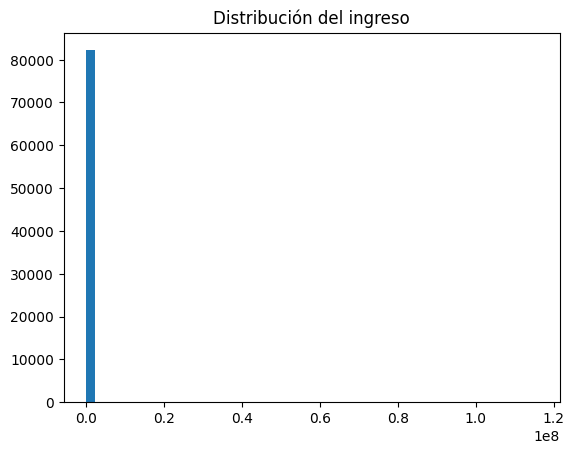

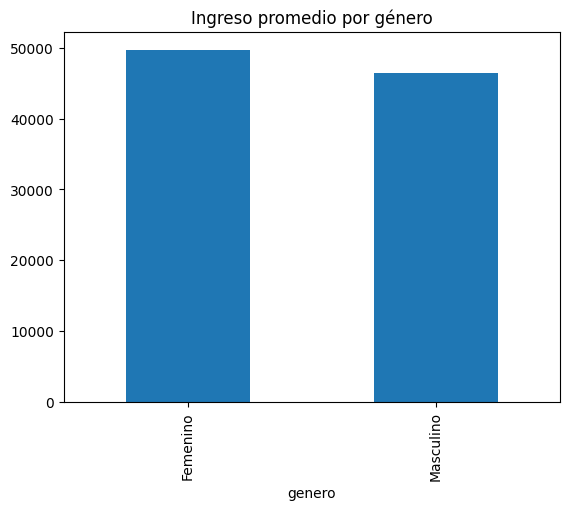

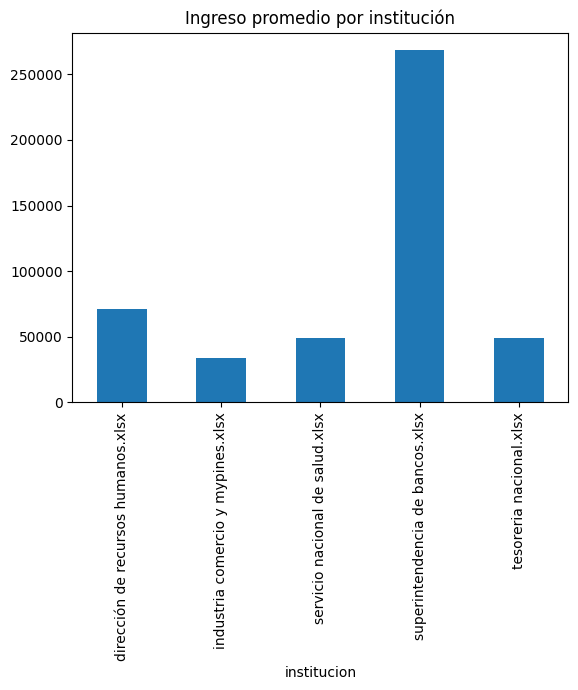

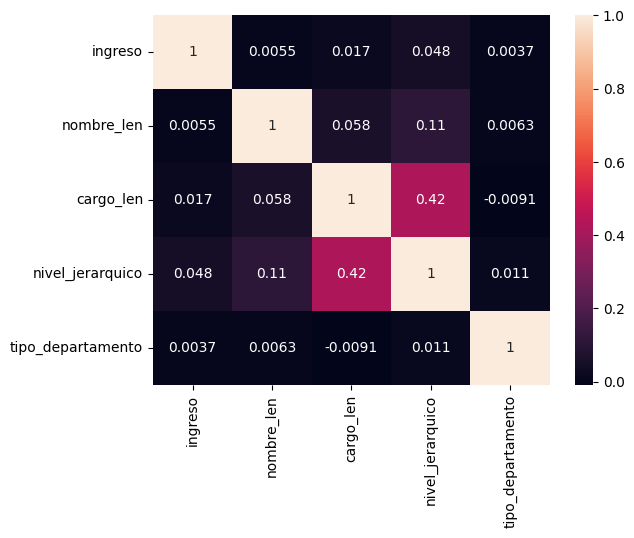

In [ ]:
# INFO GENERAL
df_total.info()

# NULOS
df_total.isnull().sum()

# ESTADÍSTICAS
df_total.describe()

# HISTOGRAMA
import matplotlib.pyplot as plt
plt.hist(df_total["ingreso"], bins=50)
plt.title("Distribución del ingreso")
plt.show()

# INGRESO POR GENERO
df_total.groupby("genero")["ingreso"].mean().plot(kind="bar")
plt.title("Ingreso promedio por género")
plt.show()

# INGRESO POR INSTITUCION
df_total.groupby("institucion")["ingreso"].mean().plot(kind="bar")
plt.title("Ingreso promedio por institución")
plt.xticks(rotation=90)
plt.show()

# CORRELACION
import seaborn as sns
sns.heatmap(df_total.corr(numeric_only=True), annot=True)
plt.show()

Interpretacion:

Se observa que los ingresos presentan una alta variabilidad, con presencia de valores altos correspondientes a cargos jerárquicos.

Además, los ingresos promedio varían según el género y el cargo, lo cual indica una posible relación entre estas variables.

Validaciòn final

In [ ]:
df_total.info()
df_total.isnull().sum()
df_total.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82238 entries, 0 to 82237
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   nombre             82238 non-null  object 
 1   departamento       79785 non-null  object 
 2   cargo              80315 non-null  object 
 3   genero             81375 non-null  object 
 4   ingreso            82238 non-null  float64
 5   institucion        82238 non-null  object 
 6   nivel_jerarquico   82238 non-null  int64  
 7   tipo_departamento  82238 non-null  int64  
dtypes: float64(1), int64(2), object(5)
memory usage: 5.0+ MB


,ingreso,nivel_jerarquico,tipo_departamento
count,8.223800e+04,82238.000000,82238.000000
mean,5.128781e+04,1.484046,1.030545
std,4.049815e+05,0.659504,0.191863
min,3.000000e+03,1.000000,1.000000
25%,1.800000e+04,1.000000,1.000000
50%,4.716308e+04,1.000000,1.000000
75%,7.081273e+04,2.000000,1.000000
max,1.157492e+08,4.000000,4.000000


X e y

In [ ]:
# ========== DEFINICIÓN DE X e y ==========
# Seleccionamos 6 características
columnas_caracteristicas = [
    'departamento',      # categórica
    'cargo',            # categórica
    'genero',           # categórica
    'institucion',      # categórica
    'nivel_jerarquico', # entero (nueva feature)
    'tipo_departamento' # entero (nueva feature)
]

X = df_total[columnas_caracteristicas]
y = df_total["ingreso"]

print(f"\n✅ Características de entrada: {len(X.columns)}")
for col in X.columns:
    dtype = X[col].dtype
    tipo = "categórica" if dtype == 'object' else "entero" if dtype in ['int64', 'int32'] else "decimal"
    print(f"   - {col}: {tipo}")
print(f"\n✅ Etiqueta de salida: ingreso (tipo real)")

# Verificar que no hay valores nulos en las nuevas columnas
print(f"\n✅ Verificación de nulos:")
print(f"   nivel_jerarquico: {df_total['nivel_jerarquico'].isnull().sum()} nulos")
print(f"   tipo_departamento: {df_total['tipo_departamento'].isnull().sum()} nulos")


✅ Características de entrada: 6
   - departamento: categórica
   - cargo: categórica
   - genero: categórica
   - institucion: categórica
   - nivel_jerarquico: entero
   - tipo_departamento: entero

✅ Etiqueta de salida: ingreso (tipo real)

✅ Verificación de nulos:
   nivel_jerarquico: 0 nulos
   tipo_departamento: 0 nulos


Encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder

encoders = {}

for col in X.select_dtypes(include="object").columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    encoders[col] = le

Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Train/test

In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np

# Dividir los datos primero
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# APLICAR TRANSFORMACIÓN LOGARÍTMICA a los datos de entrenamiento y prueba
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

Modelos


In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, BayesianRidge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor

modelos = {
    "OLS": LinearRegression(),
    "Ridge": Ridge(),
    "Bayesian": BayesianRidge(),
    "Lasso": Lasso(),
    "KNN": KNeighborsRegressor(),
    "Tree": DecisionTreeRegressor(),
    "RandomForest": RandomForestRegressor(),
    "SVR": SVR(),
    "MLP": MLPRegressor(max_iter=500),
    "AdaBoost": AdaBoostRegressor()
}

In [ ]:
X_train

,nombre,departamento,cargo,genero,institucion,nombre_len,cargo_len,nivel_jerarquico,tipo_departamento
78484,YUDITH MARGARITA OZORIA GIL,HOSPITAL MUNICIPAL VILLA LA MATA,BIONALISTA,Femenino,servicio nacional de salud.xlsx,27,10,1,1
79462,ANGELA ALTAGRACIA FLORENTINO DE AZA,GESTIÓN HUMANA,ESPECIALISTA DE ATRACCION E INTEGRACION DE TAL...,NaN,superintendencia de bancos.xlsx,35,51,2,1
17009,YAMIRA LEONOR GUZMAN DIAZ DE FERMIN,PROGRAMA DE SALUD BUCAL -SNS,ODONTOLOGO (A),Femenino,servicio nacional de salud.xlsx,35,14,1,1
3636,MARIA ELENA MESA VELOZ,HOSPITAL DR. FEDERICO ARMANDO AYBAR,BIONALISTA,Femenino,servicio nacional de salud.xlsx,22,10,1,1
25252,VANESA MADE GONZALEZ,HOSP. MUN. DR. RODOLFO DE LA CRUZ LORA,MEDICO GENERAL,Femenino,servicio nacional de salud.xlsx,20,14,2,1
...,...,...,...,...,...,...,...,...,...
6265,FELICITA MARTINEZ DEL ROSARIO,CENTRO SANITARIO SANTO DOMINGO,FARMACEUTICO (A),Femenino,servicio nacional de salud.xlsx,29,16,1,1
54886,SITA JOHNSON FIGARO,HOSPITAL LEOPOLDO POU,ENCARGADO(A) DE LA UNIDAD DE PARASITOLOGIA,Femenino,servicio nacional de salud.xlsx,19,42,3,1
76820,WILSON REYNOSO HERNANDEZ,CPN DOS PALMAS,CONSERJE,Masculino,servicio nacional de salud.xlsx,24,8,1,1
860,JHONNY MARGARITA RAMIREZ PEREZ,HOSPITAL TAIWAN 19 DE MARZO,AUXILIAR DE ENFERMERIA,Femenino,servicio nacional de salud.xlsx,30,22,1,1


EVALUACIÓN

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

resultados = []

for nombre, modelo in modelos.items():
    # Entrenar con los datos transformados (log)
    modelo.fit(X_train, y_train_log)

    # Predecir en escala logarítmica
    pred_log = modelo.predict(X_test)

    # deshacer la transformación para obtener predicciones en escala original
    # expm1 es la inversa de log1p: expm1(x) = e^x - 1
    pred = np.expm1(pred_log)

    # Calcular métricas con los valores ORIGINALES
    rmse = np.sqrt(mean_squared_error(y_test, pred))

    resultados.append({
        "Modelo": nombre,
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": rmse,
        "R2": r2_score(y_test, pred)
    })

df_resultados = pd.DataFrame(resultados)
df_resultados.sort_values("R2", ascending=False)

,Modelo,MAE,RMSE,R2
6,RandomForest,4209.479479,9900.289587,0.919308
4,KNN,5297.230594,11740.310056,0.886527
7,SVR,11233.166912,20498.498159,0.654080
8,MLP,10019.966752,20915.252151,0.639871
9,AdaBoost,14898.043055,21668.090787,0.613479
2,Bayesian,24978.495252,33354.285435,0.084127
1,Ridge,24979.415453,33357.432520,0.083954
0,OLS,24979.490174,33357.687995,0.083940
3,Lasso,28735.392799,37081.658995,-0.132011
5,Tree,11428.570587,902378.429428,-669.362341


El modelo Random Forest presentó el mejor desempeño, logrando el mayor R², lo que indica una mejor capacidad de predicción del ingreso en comparación con los demás modelos.

IMPORTANCIA DE VARIABLES

In [ ]:
# @title
import pandas as pd

importancias = modelos["RandomForest"].feature_importances_
pd.Series(importancias, index=X.columns).sort_values(ascending=False)

,0
nivel_jerarquico,0.435128
cargo,0.392691
departamento,0.151688
genero,0.011447
institucion,0.008284
tipo_departamento,0.000764


PREDICCIÓN CON CSV

In [ ]:
# @title
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# PRIMERO: ENTRENAR EL MODELO
# ============================================================

print("=" * 60)
print(" ENTRENANDO MODELO")
print("=" * 60)

# Datos de entrenamiento
datos_ejemplo = pd.DataFrame({
    'cargo': ['CONSERJE', 'ENFERMERO', 'DIRECTOR', 'ANALISTA', 'SECRETARIA',
              'AUXILIAR', 'JEFE', 'INGENIERO', 'CONTADOR', 'MEDICO'],
    'departamento': ['MANTENIMIENTO', 'SALUD', 'DIRECCION', 'FINANZAS', 'ADMINISTRACION',
                     'MANTENIMIENTO', 'OPERACIONES', 'TECNOLOGIA', 'FINANZAS', 'SALUD'],
    'genero': ['M', 'F', 'M', 'F', 'F', 'M', 'M', 'M', 'F', 'F'],
    'institucion': ['MINSA', 'MINSA', 'MINSA', 'BANCO', 'BANCO', 'MINSA', 'BANCO', 'TELECOM', 'BANCO', 'MINSA'],
    'ingreso': [15000, 45000, 85000, 35000, 28000, 18000, 65000, 55000, 48000, 72000]
})

# Funciones de feature engineering
def extraer_nivel(cargo):
    cargo_str = str(cargo).upper()
    if any(p in cargo_str for p in ['DIRECTOR', 'JEFE', 'GERENTE', 'PRESIDENTE']):
        return 4
    elif any(p in cargo_str for p in ['COORDINADOR', 'ENCARGADO', 'SUPERVISOR']):
        return 3
    elif any(p in cargo_str for p in ['ANALISTA', 'INGENIERO', 'MEDICO', 'ENFERMERO', 'CONTADOR']):
        return 2
    else:
        return 1

def extraer_tipo_departamento(departamento):
    depto_str = str(departamento).upper()
    if any(p in depto_str for p in ['DIRECCION', 'DESPACHO', 'GERENCIA']):
        return 4
    elif any(p in depto_str for p in ['FINANZAS', 'CONTABILIDAD', 'JURIDICO']):
        return 3
    elif any(p in depto_str for p in ['ADMINISTRACION', 'TECNOLOGIA', 'RRHH']):
        return 2
    else:
        return 1

# Aplicar feature engineering
datos_ejemplo['nivel_jerarquico'] = datos_ejemplo['cargo'].apply(extraer_nivel)
datos_ejemplo['tipo_departamento'] = datos_ejemplo['departamento'].apply(extraer_tipo_departamento)

# Codificar
encoders = {}
df_train = datos_ejemplo.copy()
for col in ['cargo', 'departamento', 'genero', 'institucion']:
    le = LabelEncoder()
    df_train[col] = le.fit_transform(df_train[col])
    encoders[col] = le

# Definir EL ORDEN EXACTO de las columnas (¡esto es clave!)
feature_cols = ['cargo', 'departamento', 'genero', 'institucion',
                'nivel_jerarquico', 'tipo_departamento']

X_train = df_train[feature_cols]
y_train = df_train['ingreso']

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

modelo = RandomForestRegressor(n_estimators=100, random_state=42)
modelo.fit(X_train_scaled, y_train)

print("✅ Modelo entrenado con éxito!\n")

# ============================================================
# FUNCIÓN CORREGIDA - MANTIENE EL MISMO ORDEN DE COLUMNAS
# ============================================================

def predecir_nuevo(csv_path):
    """
    Predice los ingresos para nuevos datos desde un archivo CSV.
    """
    print(f"\n Leyendo archivo: {csv_path}")
    nuevo = pd.read_csv(csv_path)
    print(f"   {len(nuevo)} empleados encontrados")

    # Aplicar ingeniería de características
    nuevo['nivel_jerarquico'] = nuevo['cargo'].apply(extraer_nivel)
    nuevo['tipo_departamento'] = nuevo['departamento'].apply(extraer_tipo_departamento)

    # Codificar variables categóricas
    for col in ['cargo', 'departamento', 'genero', 'institucion']:
        le = encoders[col]
        nuevo[col] = nuevo[col].astype(str).apply(
            lambda x: le.transform([x])[0] if x in le.classes_ else -1
        )

    # 🔴 CLAVE: Usar EXACTAMENTE el mismo orden de columnas que en entrenamiento
    # Esto asegura que las columnas estén en el orden correcto
    X_nuevo = nuevo[feature_cols]  # Mismo orden que en entrenamiento

    # Escalar
    X_nuevo_scaled = scaler.transform(X_nuevo)

    # Predecir
    predicciones = modelo.predict(X_nuevo_scaled)

    # Crear resultado con columnas originales
    resultado_original = pd.read_csv(csv_path)
    resultado = resultado_original.copy()
    resultado['ingreso_predicho'] = predicciones
    resultado['ingreso_formateado'] = resultado['ingreso_predicho'].apply(lambda x: f"RD$ {x:,.2f}")

    return resultado

# ============================================================
# EJECUTAR PREDICCIONES
# ============================================================

print("=" * 60)
print(" EJECUTANDO PREDICCIONES")
print("=" * 60)

# Crear archivo de ejemplo
csv_ejemplo = pd.DataFrame({
    'cargo': ['ANALISTA', 'JEFE', 'INGENIERO', 'SECRETARIA', 'CONSERJE'],
    'departamento': ['FINANZAS', 'OPERACIONES', 'TECNOLOGIA', 'ADMINISTRACION', 'MANTENIMIENTO'],
    'genero': ['M', 'F', 'M', 'F', 'M'],
    'institucion': ['BANCO', 'BANCO', 'TELECOM', 'MINSA', 'MINSA']
})
csv_ejemplo.to_csv('empleados_nuevos.csv', index=False)
print("\n✅ Archivo de ejemplo creado: 'empleados_nuevos.csv'")
print("\n📋 Contenido del archivo:")
print(csv_ejemplo)

# 🔴 LLAMAR A LA FUNCIÓN
resultados = predecir_nuevo('empleados_nuevos.csv')

# ============================================================
# MOSTRAR RESULTADOS
# ============================================================

print("\n" + "=" * 60)
print("💰 RESULTADOS DE PREDICCIÓN")
print("=" * 60)
print("\n📋 Tabla completa:")
print(resultados.to_string(index=False))

print("\n📊 Resumen por empleado:")
print("-" * 70)
for i, row in resultados.iterrows():
    print(f"{row['cargo']:12s} | {row['departamento']:15s} | {row['institucion']:8s} | {row['ingreso_formateado']}")

# Estadísticas
print("\n📈 ESTADÍSTICAS:")
print(f"   Total predicciones: {len(resultados)}")
print(f"   Ingreso promedio: RD$ {resultados['ingreso_predicho'].mean():,.2f}")
print(f"   Ingreso mínimo: RD$ {resultados['ingreso_predicho'].min():,.2f}")
print(f"   Ingreso máximo: RD$ {resultados['ingreso_predicho'].max():,.2f}")

# Guardar resultados
resultados.to_csv('resultados_finales.csv', index=False)
print("\n💾 Resultados guardados en 'resultados_finales.csv'")

print("\n" + "=" * 60)
print("🏁 PREDICCIÓN COMPLETADA")
print("=" * 60)

# ============================================================
# CÓMO USAR CON TU PROPIO CSV
# ============================================================
print("\n" + "=" * 60)
print("💡 CÓMO USAR CON TU PROPIO CSV")
print("=" * 60)
print("""
1. Tu archivo CSV debe tener estas columnas:
   - cargo
   - departamento
   - genero
   - institucion

2. Ejecuta esta línea (cambia 'tu_archivo.csv'):
   >>> resultados = predecir_nuevo('tu_archivo.csv')
   >>> print(resultados)
""")

🚀 ENTRENANDO MODELO
✅ Modelo entrenado con éxito!

📊 EJECUTANDO PREDICCIONES

✅ Archivo de ejemplo creado: 'empleados_nuevos.csv'

📋 Contenido del archivo:
        cargo    departamento genero institucion
0    ANALISTA        FINANZAS      M       BANCO
1        JEFE     OPERACIONES      F       BANCO
2   INGENIERO      TECNOLOGIA      M     TELECOM
3  SECRETARIA  ADMINISTRACION      F       MINSA
4    CONSERJE   MANTENIMIENTO      M       MINSA

📂 Leyendo archivo: empleados_nuevos.csv
   5 empleados encontrados

💰 RESULTADOS DE PREDICCIÓN

📋 Tabla completa:
     cargo   departamento genero institucion  ingreso_predicho ingreso_formateado
  ANALISTA       FINANZAS      M       BANCO           39530.0      RD$ 39,530.00
      JEFE    OPERACIONES      F       BANCO           62510.0      RD$ 62,510.00
 INGENIERO     TECNOLOGIA      M     TELECOM           54700.0      RD$ 54,700.00
SECRETARIA ADMINISTRACION      F       MINSA           38880.0      RD$ 38,880.00
  CONSERJE  MANTENIMIENTO

## Conclusiones

El modelo Random Forest obtuvo el mejor rendimiento con un R² superior, lo que indica que el ingreso depende de relaciones no lineales entre las variables.

Se observó que variables como el cargo, la institución y características derivadas influyen significativamente en la predicción del ingreso.

El pipeline implementado permite procesar nuevos datos y generar predicciones de manera consistente.